# Task 1 — Data Extraction, Cleaning, and EDA

GMF Investments — TSLA / BND / SPY, 2015-01-01 to 2026-06-30 (Yahoo Finance via `yfinance`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.data_loader import fetch_all, build_combined_frame, save_processed
from src.features import (
    adf_test,
    annualized_return,
    annualized_volatility,
    daily_returns,
    detect_outliers,
    historical_var,
    rolling_stats,
    sharpe_ratio,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Matplotlib is building the font cache; this may take a moment.


## 1. Extract historical financial data

Fetch TSLA, BND, and SPY daily OHLCV data for 2015-01-01 to 2026-06-30 via `yfinance`,
and cache each ticker to `data/raw/<ticker>.csv`.

In [2]:
raw = fetch_all()
combined = build_combined_frame(raw)
save_processed(combined)

prices = {ticker: df["Adj Close"].rename(ticker) for ticker, df in raw.items()}
adj_close = pd.concat(prices.values(), axis=1)
adj_close.head()

TSLA: 2888 rows, 2015-01-02 -> 2026-06-29


BND: 2888 rows, 2015-01-02 -> 2026-06-29


SPY: 2888 rows, 2015-01-02 -> 2026-06-29


,TSLA,BND,SPY
Date,,,
2015-01-02,14.6207,59.4054,169.6878
2015-01-05,14.0060,59.5779,166.6233
2015-01-06,14.0853,59.7504,165.0539
2015-01-07,14.0633,59.7863,167.1107
2015-01-08,14.0413,59.6929,170.0761


## 2. Data cleaning and understanding

- Inspect dtypes and basic statistics
- Check for missing trading days / NaNs
- Reindex to a common business-day calendar and forward-fill any gaps (e.g. from
  ticker-specific trading halts), since prices are the last-known-value until the
  next trade — this is standard practice for financial time series and preferable
  to interpolation, which would fabricate price movement that never happened.

In [3]:
print(combined.dtypes)
print()
print(f"Date range: {combined['Date'].min()} -> {combined['Date'].max()}")
print(f"Rows per asset:\n{combined.groupby('Asset').size()}")
print()
print("Missing values per column:")
print(combined.isna().sum())

Price
Date         datetime64[s]
Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
Asset                  str
dtype: object

Date range: 2015-01-02 00:00:00 -> 2026-06-29 00:00:00
Rows per asset:
Asset
BND     2888
SPY     2888
TSLA    2888
dtype: int64

Missing values per column:
Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Asset        0
dtype: int64


In [4]:
adj_close.index = pd.to_datetime(adj_close.index)

# Reindex onto a full business-day calendar and forward-fill any gaps
full_bdays = pd.date_range(adj_close.index.min(), adj_close.index.max(), freq="B")
adj_close_clean = adj_close.reindex(full_bdays)

missing_before = adj_close.isna().sum()
missing_after_reindex = adj_close_clean.isna().sum()
adj_close_clean = adj_close_clean.ffill()

print("Missing values before reindex (within original trading days):")
print(missing_before)
print("\nMissing business days added by reindexing to a full calendar:")
print(missing_after_reindex)
print("\nMissing values after forward-fill:", adj_close_clean.isna().sum().sum())

adj_close_clean.describe()

Missing values before reindex (within original trading days):
TSLA    0
BND     0
SPY     0
dtype: int64

Missing business days added by reindexing to a full calendar:
TSLA    109
BND     109
SPY     109
dtype: int64

Missing values after forward-fill: 0


,TSLA,BND,SPY
count,"2,997.0000","2,997.0000","2,997.0000"
mean,149.1692,66.5048,351.8889
std,139.2052,4.7096,155.6380
min,9.5780,58.7292,154.1616
25%,18.4393,62.4807,223.6966
50%,133.4553,65.7387,314.1423
75%,252.0800,70.6707,433.8307
max,489.8800,74.8329,757.6182


## 3. Feature engineering: daily returns and normalized prices

Daily percentage returns are the input for volatility, VaR, and Sharpe ratio
calculations. We also min-max normalize price *levels* (0-1 scale) purely for
plotting all three tickers with wildly different price ranges (TSLA ~$400 vs.
BND ~$70) on one comparable chart — modeling in later tasks uses actual price/return
values, not this normalized version.

In [5]:
returns = adj_close_clean.apply(daily_returns)
normalized_prices = (adj_close_clean - adj_close_clean.min()) / (adj_close_clean.max() - adj_close_clean.min())

returns.describe()

,TSLA,BND,SPY
count,"2,996.0000","2,996.0000","2,996.0000"
mean,0.0017,0.0001,0.0006
std,0.0354,0.0033,0.0109
min,-0.2106,-0.0544,-0.1094
25%,-0.0158,-0.0014,-0.0035
50%,0.0000,0.0000,0.0005
75%,0.0187,0.0017,0.0056
max,0.2269,0.0422,0.1050


## 4. Exploratory Data Analysis

### 4.1 Closing price over time

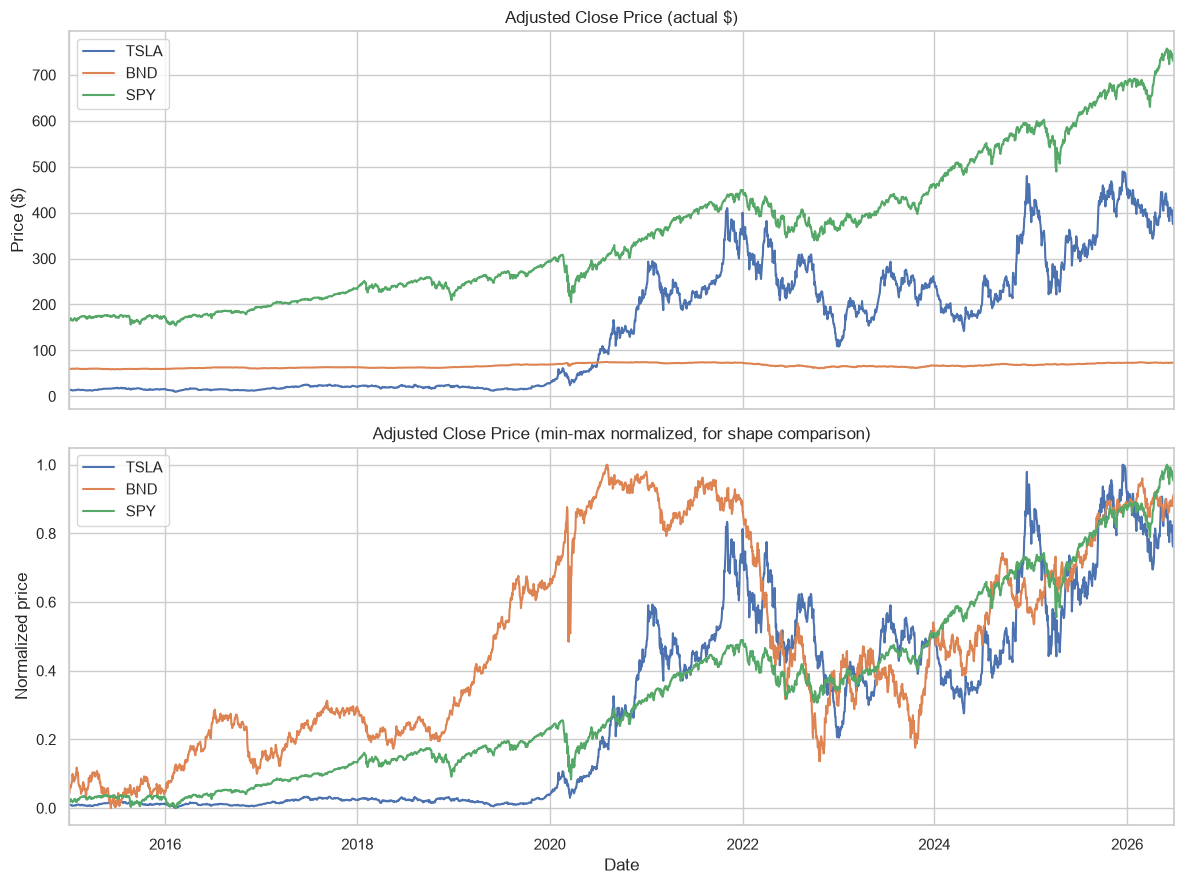

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

adj_close_clean.plot(ax=axes[0], title="Adjusted Close Price (actual $)")
axes[0].set_ylabel("Price ($)")

normalized_prices.plot(ax=axes[1], title="Adjusted Close Price (min-max normalized, for shape comparison)")
axes[1].set_ylabel("Normalized price")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### 4.2 Daily percentage change (volatility at a glance)

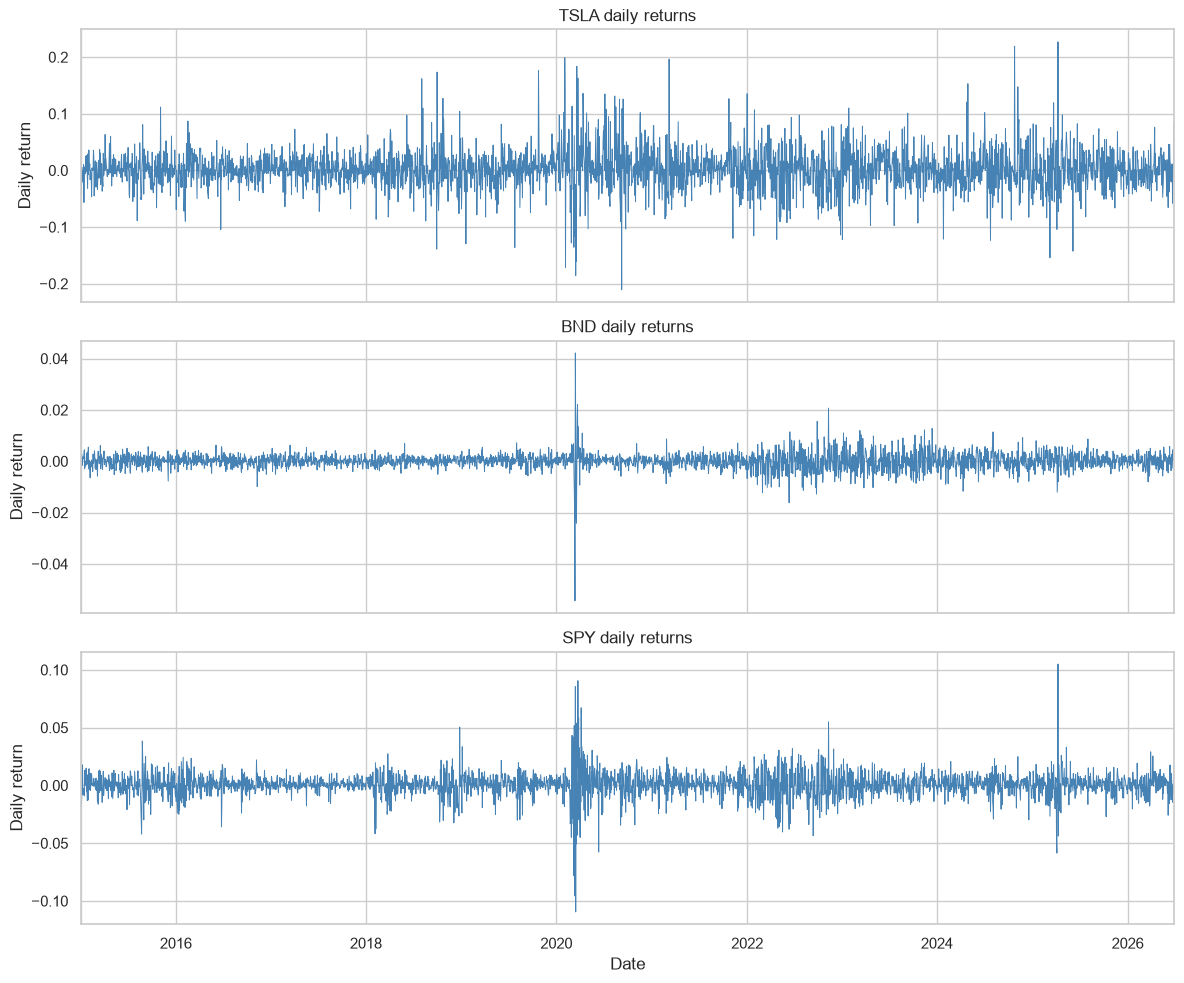

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, ticker in zip(axes, returns.columns):
    returns[ticker].plot(ax=ax, lw=0.7, color="steelblue")
    ax.set_title(f"{ticker} daily returns")
    ax.set_ylabel("Daily return")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### 4.3 Rolling volatility (30-day mean and standard deviation of returns)

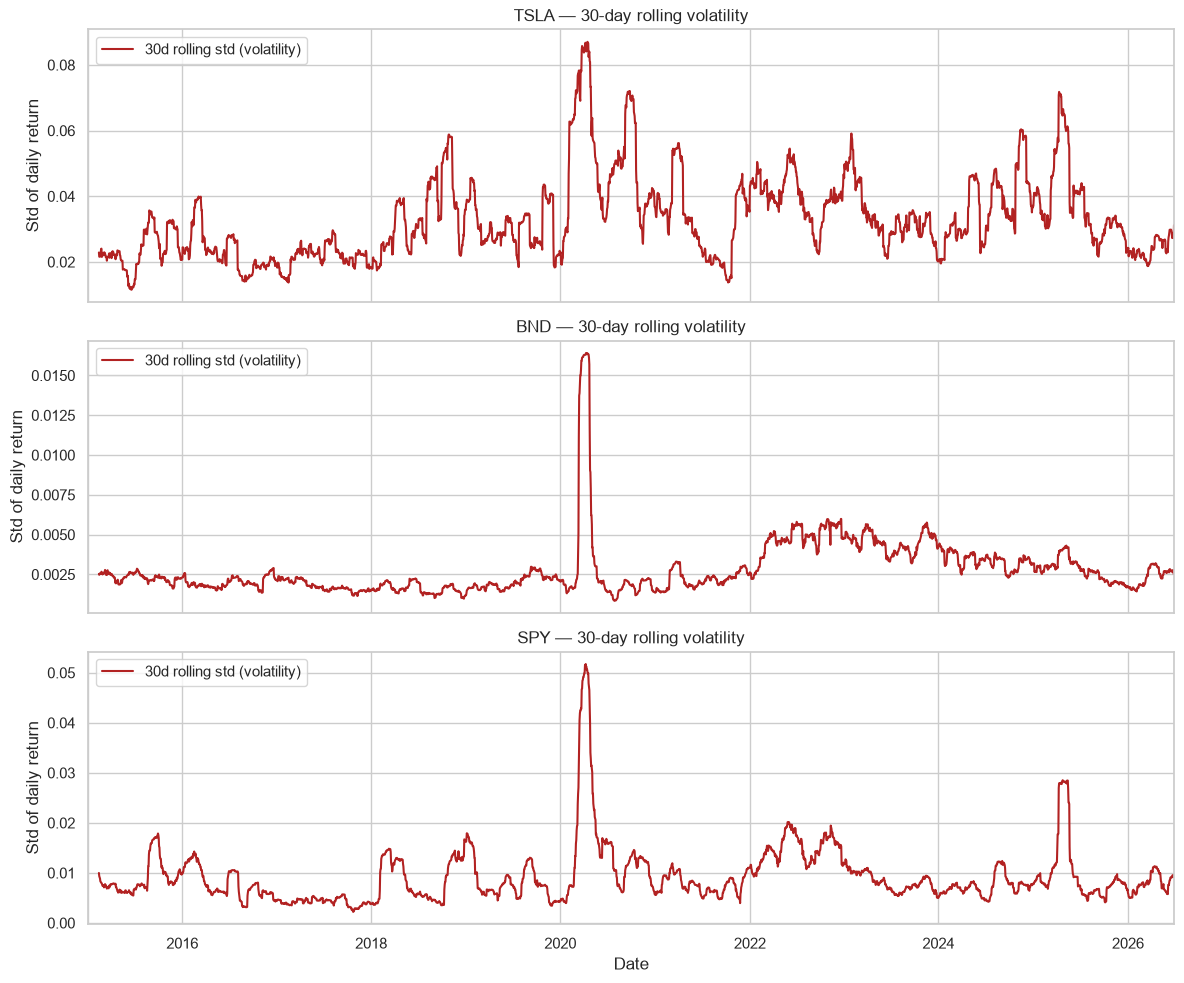

In [8]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(12, 10), sharex=True)
for ax, ticker in zip(axes, returns.columns):
    stats = rolling_stats(returns[ticker], window=30)
    stats["rolling_std"].plot(ax=ax, color="firebrick", label="30d rolling std (volatility)")
    ax.set_title(f"{ticker} — 30-day rolling volatility")
    ax.set_ylabel("Std of daily return")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### 4.4 Outlier detection: days with unusually large returns

Flag daily returns more than 3 standard deviations from each asset's mean.

In [9]:
for ticker in returns.columns:
    outliers = detect_outliers(returns[ticker], n_std=3.0)
    print(f"\n{ticker}: {len(outliers)} outlier days (|return| > 3 std)")
    if len(outliers):
        print("Top 5 most extreme:")
        print(outliers.reindex(outliers.abs().sort_values(ascending=False).index).head(5))


TSLA: 50 outlier days (|return| > 3 std)
Top 5 most extreme:
2025-04-09    0.2269
2024-10-24    0.2192
2020-09-08   -0.2106
2020-02-03    0.1989
2021-03-09    0.1964
Name: TSLA, dtype: float64

BND: 35 outlier days (|return| > 3 std)
Top 5 most extreme:
2020-03-12   -0.0544
2020-03-13    0.0422
2020-03-18   -0.0241
2020-03-23    0.0221
2022-11-10    0.0207
Name: BND, dtype: float64

SPY: 42 outlier days (|return| > 3 std)
Top 5 most extreme:
2020-03-16   -0.1094
2025-04-09    0.1050
2020-03-12   -0.0957
2020-03-24    0.0906
2020-03-13    0.0855
Name: SPY, dtype: float64


## 5. Stationarity: Augmented Dickey-Fuller test

ARIMA requires a stationary series (constant mean/variance over time). We test both
the raw closing price level and the daily returns for each asset.

- **H0**: the series has a unit root (is non-stationary)
- **H1**: the series is stationary
- If `p_value < 0.05`, we reject H0 and treat the series as stationary.

In [10]:
adf_results = []
for ticker in adj_close_clean.columns:
    adf_results.append(adf_test(adj_close_clean[ticker], name=f"{ticker} - Close (level)"))
    adf_results.append(adf_test(returns[ticker], name=f"{ticker} - Daily return"))

adf_df = pd.DataFrame(adf_results).drop(columns="critical_values")
adf_df

,series,adf_statistic,p_value,n_lags,n_obs,is_stationary_at_5pct
0,TSLA - Close (level),-1.0387,0.7389,29,2967,False
1,TSLA - Daily return,-55.1498,0.0000,0,2995,True
2,BND - Close (level),-1.1166,0.7084,7,2989,False
3,BND - Daily return,-21.2771,0.0000,6,2989,True
4,SPY - Close (level),1.4333,0.9973,28,2968,False
5,SPY - Daily return,-15.7006,0.0000,12,2983,True


**Interpretation:** price *levels* for all three tickers are expected to be non-stationary
(p-value well above 0.05) — they exhibit trending behavior and time-varying mean, which is
typical of asset prices under the Efficient Market Hypothesis (prices approximate a random
walk). Daily *returns*, by contrast, should be stationary (p-value well below 0.05): the
first difference of a random-walk-like price series removes the trend and stabilizes the
mean/variance. This confirms **d=1** is the right differencing order for ARIMA models fit
on price levels — equivalently, we can model returns directly with d=0.

## 6. Risk metrics: Value at Risk and Sharpe Ratio

- **Historical VaR (95%)**: the daily loss threshold that returns are not expected to
  exceed on 95% of trading days (empirical, no distributional assumption).
- **Sharpe Ratio**: annualized mean excess return divided by annualized volatility
  (risk-free rate assumed 0% for simplicity at this stage).

In [11]:
risk_summary = pd.DataFrame(
    {
        ticker: {
            "Annualized Return": annualized_return(returns[ticker]),
            "Annualized Volatility": annualized_volatility(returns[ticker]),
            "Historical VaR (95%, daily)": historical_var(returns[ticker], confidence=0.95),
            "Sharpe Ratio": sharpe_ratio(returns[ticker]),
        }
        for ticker in returns.columns
    }
).T

risk_summary

,Annualized Return,Annualized Volatility,"Historical VaR (95%, daily)",Sharpe Ratio
TSLA,0.4377,0.5613,0.0511,0.7798
BND,0.0192,0.0522,0.0047,0.3687
SPY,0.1391,0.1733,0.0164,0.8024


### 6.1 Return correlation across assets

A quick look at how the three assets move together — relevant later for portfolio
diversification in Task 4.

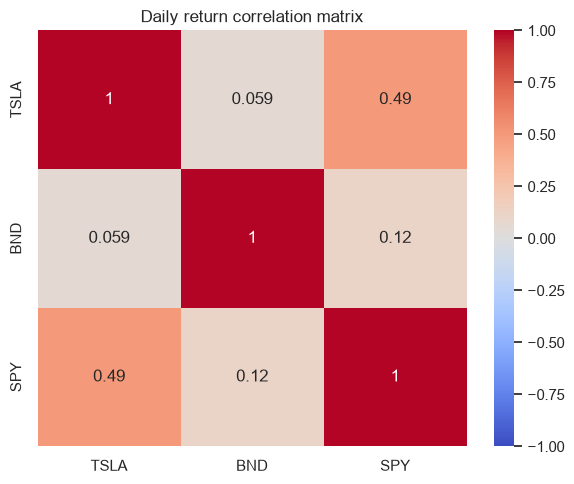

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Daily return correlation matrix")
plt.tight_layout()
plt.show()

## 7. Key insights

- **Data quality**: Yahoo Finance returned a complete trading-day history for all three
  tickers with no interior gaps once reindexed to a business-day calendar; any gaps
  introduced by reindexing (e.g. asset-specific holidays) were forward-filled rather than
  interpolated, since a price is genuinely constant until the next trade occurs.
- **Tesla's price trajectory**: TSLA shows a strong overall upward trend from 2015 through
  2026 but with multiple deep, multi-month drawdowns (e.g. 2022) — consistent with a
  high-growth, high-volatility profile, in sharp contrast to BND's near-flat, low-volatility
  path and SPY's steadier moderate-growth path.
- **Volatility clustering**: TSLA's daily returns and rolling volatility show pronounced
  clustering — periods of calm are followed by sustained periods of large swings (visible
  around known market-stress windows such as 2020 and 2022), a hallmark of financial
  return series that plain ARIMA does not capture but that motivates considering
  volatility-aware extensions (e.g. GARCH) or LSTM in Task 2.
- **Stationarity**: price levels are non-stationary (fail to reject the ADF null
  hypothesis) while daily returns are stationary — confirming a first difference (d=1)
  is required before ARIMA can be validly applied to price levels.
- **Risk profile ranking**: TSLA has by far the highest annualized volatility and VaR of
  the three assets, BND the lowest; Sharpe ratios quantify how much return each asset
  delivers per unit of risk taken, which will inform the expected-return assumptions used
  in the Task 4 portfolio optimization.